In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

PROJECT_DIR = Path.cwd().parent

print("Project:", PROJECT_DIR)

TensorFlow: 2.21.0
GPU: []
Project: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI


In [3]:
from pathlib import Path

EMOTION_DIR = PROJECT_DIR / "data" / "emotion"

TRAIN_DIR = EMOTION_DIR / "train"
TEST_DIR = EMOTION_DIR / "test"

print("Emotion dataset:", EMOTION_DIR)
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

if TRAIN_DIR.exists():
    train_classes = sorted(
        [
            folder.name
            for folder in TRAIN_DIR.iterdir()
            if folder.is_dir()
        ]
    )
    print("\nTrain classes:")
    print(train_classes)

if TEST_DIR.exists():
    test_classes = sorted(
        [
            folder.name
            for folder in TEST_DIR.iterdir()
            if folder.is_dir()
        ]
    )
    print("\nTest classes:")
    print(test_classes)

Emotion dataset: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\emotion
Train folder exists: True
Test folder exists: True

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
# ============================================================
# FAST FER-2013 DATA LOADING
# ============================================================

IMG_SIZE = (48, 48)
BATCH_SIZE = 128
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.15,
    subset="training",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.15,
    subset="validation",
)

class_names = train_ds.class_names

print("\nClasses:")
print(class_names)

print("\nTraining batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 28709 files belonging to 7 classes.
Using 24403 files for training.
Found 28709 files belonging to 7 classes.
Using 4306 files for validation.

Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Training batches: 191
Validation batches: 34


In [5]:
# ============================================================
# FAST EMOTION CNN
# ============================================================

emotion_model = tf.keras.Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    # Normalization
    tf.keras.layers.Rescaling(1.0 / 255.0),

    # Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Reduce parameters
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.35),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(
        7,
        activation="softmax"
    )
])


emotion_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


emotion_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,983 (433.53 KB)

 Trainable params: 110,535 (431.78 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# ============================================================
# TRAINING CALLBACKS
# ============================================================

MODEL_PATH = PROJECT_DIR / "models" / "emotion_model_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1
    )
]

print("Best model will be saved to:")
print(MODEL_PATH)

Best model will be saved to:
c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras


In [7]:
# ============================================================
# FAST EMOTION MODEL TRAINING
# ============================================================

EPOCHS = 20

print("Starting emotion model training...")
print("Epochs:", EPOCHS)
print("Training images: 24,403")
print("Validation images: 4,306")
print("Batch size:", BATCH_SIZE)
print()

history = emotion_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed.")

Starting emotion model training...
Epochs: 20
Training images: 24,403
Validation images: 4,306
Batch size: 128

Epoch 1/20


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.2564 - loss: 1.8308
Epoch 1: val_accuracy improved from None to 0.17301, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 188s 861ms/step - accuracy: 0.2564 - loss: 1.8308 - val_accuracy: 0.1730 - val_loss: 2.1031 - learning_rate: 0.0010
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.3439 - loss: 1.6422
Epoch 2: val_accuracy did not improve from 0.17301

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
191/191 ━━━━━━━━━━━━━━━━━━━━ 179s 740ms/step - accuracy: 0.3439 - loss: 1.6422 - val_accuracy: 0.1719 - val_loss: 2.2925 - learning_rate: 0.0010
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.4196 - loss: 1.4911
Epoch 3: val_accuracy improved from 0.17301

In [8]:
# Load the best saved emotion model
best_emotion_model = tf.keras.models.load_model(MODEL_PATH)

print("Best emotion model loaded.")
print("Model path:", MODEL_PATH)

# Evaluate on validation dataset
val_loss, val_accuracy = best_emotion_model.evaluate(
    val_ds,
    verbose=1
)

print("\n===== Emotion Model Validation Result =====")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")

Best emotion model loaded.
Model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.5743 - loss: 1.1429

===== Emotion Model Validation Result =====
Validation Loss     : 1.1429
Validation Accuracy : 57.43%


In [9]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_emotion_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("===== Emotion Classification Report =====\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== Emotion Classification Report =====

              precision    recall  f1-score   support

       angry     0.4870    0.4229    0.4527       577
     disgust     0.5455    0.1277    0.2069        47
        fear     0.4656    0.2780    0.3482       633
       happy     0.7255    0.8385    0.7779      1040
     neutral     0.5116    0.5649    0.5369       740
         sad     0.4344    0.5127    0.4703       749
    surprise     0.7271    0.7173    0.7222       520

    accuracy                         0.5743      4306
   macro avg     0.5567    0.4946    0.5021      4306
weighted avg     0.5662    0.5743    0.5633      4306



In [10]:
from sklearn.utils.class_weight import compute_class_weight

# Get training labels
train_labels = []

for _, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate balanced weights
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_labels
)

# Use square root to make the weighting less aggressive
moderate_weights = np.sqrt(raw_weights)

class_weights = {
    i: float(moderate_weights[i])
    for i in range(len(class_names))
}

print("===== Moderate Class Weights =====")


for i, class_name in enumerate(class_names):
    print(f"{class_name:10s} : {class_weights[i]:.3f}")

===== Moderate Class Weights =====
angry      : 1.010
disgust    : 2.994
fear       : 1.003
happy      : 0.751
neutral    : 0.908
sad        : 0.924
surprise   : 1.147


In [11]:
# Rebuild a fresh model so this is a clean training run

emotion_model_balanced = tf.keras.Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    tf.keras.layers.Rescaling(1.0 / 255.0),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.35),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(
        7,
        activation="softmax"
    )
])

emotion_model_balanced.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

BALANCED_MODEL_PATH = (
    PROJECT_DIR /
    "models" /
    "emotion_model_balanced_best.keras"
)

balanced_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BALANCED_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

print("Balanced emotion model created.")
print("Parameters:", emotion_model_balanced.count_params())
print("Save path:", BALANCED_MODEL_PATH)

Balanced emotion model created.
Parameters: 110983
Save path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_balanced_best.keras


In [12]:
EPOCHS_BALANCED = 20

print("Starting balanced emotion model training...")
print("Epochs:", EPOCHS_BALANCED)
print("Training images: 24,403")
print("Validation images: 4,306")
print("Batch size:", BATCH_SIZE)
print("Using moderate class weights:")
print(class_weights)
print()

balanced_history = emotion_model_balanced.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BALANCED,
    class_weight=class_weights,
    callbacks=balanced_callbacks,
    verbose=1
)

print("\nBalanced training completed.")

Starting balanced emotion model training...
Epochs: 20
Training images: 24,403
Validation images: 4,306
Batch size: 128
Using moderate class weights:
{0: 1.0099190416983532, 1: 2.993627704091047, 2: 1.0031910484925848, 3: 0.7513704463947477, 4: 0.9083625761434442, 5: 0.9242496452788358, 6: 1.1467472995264814}

Epoch 1/20


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.2216 - loss: 1.8730
Epoch 1: val_accuracy improved from None to 0.17394, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_balanced_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_balanced_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 162s 757ms/step - accuracy: 0.2216 - loss: 1.8730 - val_accuracy: 0.1739 - val_loss: 2.0688 - learning_rate: 5.0000e-04
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.2670 - loss: 1.7715
Epoch 2: val_accuracy improved from 0.17394 to 0.22341, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_balanced_best.keras

Epoch 2: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_balanced_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 154s 801ms/step - accuracy: 0.2670 - loss: 1.7

In [13]:
# Load the best balanced model
best_balanced_emotion_model = tf.keras.models.load_model(
    BALANCED_MODEL_PATH
)

print("Best balanced emotion model loaded.")
print("Model path:", BALANCED_MODEL_PATH)

# Generate predictions
y_true_balanced = []
y_pred_balanced = []

for images, labels in val_ds:
    predictions = best_balanced_emotion_model.predict(
        images,
        verbose=0
    )

    y_true_balanced.extend(labels.numpy())
    y_pred_balanced.extend(np.argmax(predictions, axis=1))

y_true_balanced = np.array(y_true_balanced)
y_pred_balanced = np.array(y_pred_balanced)

print("\n===== Balanced Emotion Classification Report =====\n")

print(
    classification_report(
        y_true_balanced,
        y_pred_balanced,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Best balanced emotion model loaded.
Model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_balanced_best.keras

===== Balanced Emotion Classification Report =====

              precision    recall  f1-score   support

       angry     0.4645    0.4645    0.4645       577
     disgust     0.5588    0.4043    0.4691        47
        fear     0.4130    0.2101    0.2785       633
       happy     0.7939    0.7558    0.7744      1040
     neutral     0.4782    0.5919    0.5290       740
         sad     0.4505    0.5527    0.4964       749
    surprise     0.6953    0.7327    0.7135       520

    accuracy                         0.5664      4306
   macro avg     0.5506    0.5303    0.5322      4306
weighted avg     0.5653    0.5664    0.5588      4306



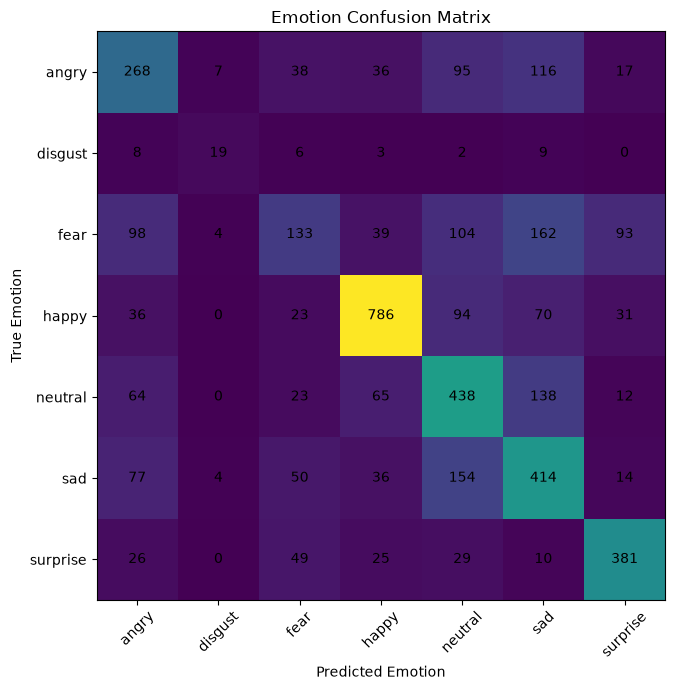

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true_balanced,
    y_pred_balanced
)

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title("Emotion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [15]:
# Data augmentation for emotion recognition

emotion_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        mode="horizontal"
    ),
    tf.keras.layers.RandomRotation(
        0.08
    ),
    tf.keras.layers.RandomZoom(
        0.10
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    ),
    tf.keras.layers.RandomContrast(
        0.10
    )
], name="emotion_augmentation")


# Create a fresh model
emotion_model_augmented = tf.keras.Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    emotion_augmentation,

    tf.keras.layers.Rescaling(1.0 / 255.0),

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.35),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(
        7,
        activation="softmax"
    )
])


emotion_model_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


AUGMENTED_MODEL_PATH = (
    PROJECT_DIR /
    "models" /
    "emotion_model_augmented_best.keras"
)


augmented_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=AUGMENTED_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]


print("Augmented emotion model created.")
print("Parameters:", emotion_model_augmented.count_params())
print("Save path:", AUGMENTED_MODEL_PATH)

Augmented emotion model created.
Parameters: 110983
Save path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_augmented_best.keras


In [16]:
EPOCHS_AUGMENTED = 20

print("Starting augmented + balanced emotion model training...")
print("Epochs:", EPOCHS_AUGMENTED)
print("Training images: 24,403")
print("Validation images: 4,306")
print("Batch size:", BATCH_SIZE)
print()

augmented_history = emotion_model_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_AUGMENTED,
    class_weight=class_weights,
    callbacks=augmented_callbacks,
    verbose=1
)

print("\nAugmented + balanced training completed.")

Starting augmented + balanced emotion model training...
Epochs: 20
Training images: 24,403
Validation images: 4,306
Batch size: 128

Epoch 1/20


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2190 - loss: 1.8770
Epoch 1: val_accuracy improved from None to 0.07942, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_augmented_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_augmented_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.2190 - loss: 1.8770 - val_accuracy: 0.0794 - val_loss: 2.1054 - learning_rate: 5.0000e-04
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2444 - loss: 1.7926
Epoch 2: val_accuracy improved from 0.07942 to 0.20320, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_augmented_best.keras

Epoch 2: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_augmented_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.2444 - loss: 1.7926 - va

In [17]:
from pathlib import Path
import tensorflow as tf

PROJECT_DIR = Path.cwd().parent

AUGMENTED_MODEL_PATH = PROJECT_DIR / "models" / "emotion_model_augmented_best.keras"

print("Model path:", AUGMENTED_MODEL_PATH)
print("Exists:", AUGMENTED_MODEL_PATH.exists())

if AUGMENTED_MODEL_PATH.exists():
    print("Model size (MB):", round(AUGMENTED_MODEL_PATH.stat().st_size / (1024 * 1024), 2))

    best_emotion_model = tf.keras.models.load_model(AUGMENTED_MODEL_PATH)

    print("\nModel loaded successfully.")
    print("Input shape:", best_emotion_model.input_shape)
    print("Output shape:", best_emotion_model.output_shape)
    print("Total parameters:", best_emotion_model.count_params())

Model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_augmented_best.keras
Exists: True
Model size (MB): 1.35

Model loaded successfully.
Input shape: (None, 48, 48, 1)
Output shape: (None, 7)
Total parameters: 110983


In [18]:
# Evaluate augmented + balanced emotion model

print("Evaluating augmented + balanced emotion model...")

augmented_results = best_emotion_model.evaluate(
    val_ds,
    verbose=1
)

print("\n===== AUGMENTED MODEL RESULTS =====")
print("Validation Loss:", round(float(augmented_results[0]), 4))
print("Validation Accuracy:", round(float(augmented_results[1]) * 100, 2), "%")

Evaluating augmented + balanced emotion model...


34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.4884 - loss: 1.3310

===== AUGMENTED MODEL RESULTS =====
Validation Loss: 1.331
Validation Accuracy: 48.84 %


In [19]:
from sklearn.metrics import classification_report
import numpy as np

print("Generating classification report...")

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_emotion_model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n===== AUGMENTED + BALANCED CLASSIFICATION REPORT =====")
print(report)

Generating classification report...

===== AUGMENTED + BALANCED CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

       angry     0.3272    0.4627    0.3833       577
     disgust     0.2222    0.0426    0.0714        47
        fear     0.3761    0.1295    0.1927       633
       happy     0.5950    0.8067    0.6849      1040
     neutral     0.4150    0.5378    0.4685       740
         sad     0.4788    0.2563    0.3339       749
    surprise     0.6552    0.6212    0.6377       520

    accuracy                         0.4884      4306
   macro avg     0.4385    0.4081    0.3961      4306
weighted avg     0.4790    0.4884    0.4615      4306



In [20]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

try:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )
    print("MobileNetV2 loaded successfully.")
    print("Parameters:", base_model.count_params())
except Exception as e:
    print("ERROR:", e)

TensorFlow: 2.21.0
MobileNetV2 loaded successfully.
Parameters: 2257984


In [21]:
# ============================================
# Transfer Learning Emotion Model
# ============================================

from tensorflow.keras import layers, models

# Freeze pretrained MobileNetV2 initially
base_model.trainable = False

emotion_tl_model = models.Sequential([
    tf.keras.Input(shape=(96, 96, 3)),

    # MobileNetV2 preprocessing
    layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.30),

    layers.Dense(7, activation="softmax")
])

emotion_tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

emotion_tl_model.summary()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in emotion_tl_model.trainable_weights
)

print("\nTransfer-learning emotion model created.")
print("Trainable parameters:", trainable_params)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Transfer-learning emotion model created.
Trainable parameters: 164871


In [22]:
    # ============================================
# FER-2013 Pipeline for MobileNetV2
# ============================================

IMG_SIZE_TL = (96, 96)
BATCH_SIZE_TL = 128
SEED_TL = 42

print("Creating 96x96 RGB FER-2013 datasets...")

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=True,
    seed=SEED_TL,
    validation_split=0.15,
    subset="training"
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    shuffle=False,
    seed=SEED_TL,
    validation_split=0.15,
    subset="validation"
)

class_names_tl = train_ds_tl.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.prefetch(AUTOTUNE)
val_ds_tl = val_ds_tl.prefetch(AUTOTUNE)

print("\nDataset ready.")
print("Classes:", class_names_tl)
print("Image size:", IMG_SIZE_TL)
print("Batch size:", BATCH_SIZE_TL)

Creating 96x96 RGB FER-2013 datasets...
Found 28709 files belonging to 7 classes.
Using 24403 files for training.
Found 28709 files belonging to 7 classes.
Using 4306 files for validation.

Dataset ready.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Image size: (96, 96)
Batch size: 128


In [23]:
# ============================================
# Verify MobileNetV2 Emotion Dataset
# ============================================

images, labels = next(iter(train_ds_tl))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Image minimum:", float(tf.reduce_min(images)))
print("Image maximum:", float(tf.reduce_max(images)))
print("Labels:", labels[:10].numpy())

Images shape: (128, 96, 96, 3)
Labels shape: (128,)
Image dtype: <dtype: 'float32'>
Image minimum: 0.0
Image maximum: 255.0
Labels: [5 3 3 5 2 0 4 3 3 0]


In [24]:
# ============================================
# Compile MobileNetV2 Emotion Model
# ============================================

emotion_tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("MobileNetV2 emotion model compiled successfully.")
print("Trainable parameters:",
      sum(
          tf.keras.backend.count_params(w)
          for w in emotion_tl_model.trainable_weights
      ))

MobileNetV2 emotion model compiled successfully.
Trainable parameters: 164871


In [25]:
# ============================================
# Train MobileNetV2 Emotion Model
# ============================================

from pathlib import Path

TL_MODEL_PATH = PROJECT_DIR / "models" / "emotion_model_mobilenetv2_best.keras"

TL_EPOCHS = 10

tl_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=TL_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

print("Starting MobileNetV2 emotion training...")
print("Epochs:", TL_EPOCHS)
print("Training images:", 24403)
print("Validation images:", 4306)
print("Batch size:", BATCH_SIZE_TL)
print("Training steps/epoch: 191")
print("Validation steps/epoch: 34")
print("Model:", TL_MODEL_PATH)

tl_history = emotion_tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=TL_EPOCHS,
    callbacks=tl_callbacks,
    verbose=1
)

print("\nMobileNetV2 emotion training completed.")

Starting MobileNetV2 emotion training...
Epochs: 10
Training images: 24403
Validation images: 4306
Batch size: 128
Training steps/epoch: 191
Validation steps/epoch: 34
Model: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_mobilenetv2_best.keras


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3027 - loss: 1.7856
Epoch 1: val_accuracy improved from None to 0.55086, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_mobilenetv2_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_mobilenetv2_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.3027 - loss: 1.7856 - val_accuracy: 0.5509 - val_loss: 1.5070 - learning_rate: 5.0000e-04
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3634 - loss: 1.6208
Epoch 2: val_accuracy improved from 0.55086 to 0.57757, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_mobilenetv2_best.keras

Epoch 2: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_mobilenetv2_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.3634 

In [27]:
# ============================================
# Load Best MobileNetV2 Model
# ============================================

print("Loading best MobileNetV2 model...")

best_tl_model = tf.keras.models.load_model(
    TL_MODEL_PATH,
    custom_objects={
        "preprocess_input": tf.keras.applications.mobilenet_v2.preprocess_input
    }
)

print("Model loaded successfully.")
print("Evaluating best checkpoint...")

tl_results = best_tl_model.evaluate(
    val_ds_tl,
    verbose=1
)

print("\n===== MOBILENETV2 RESULTS =====")
print("Validation Loss:", round(float(tl_results[0]), 4))
print("Validation Accuracy:", round(float(tl_results[1]) * 100, 2), "%")

Loading best MobileNetV2 model...


Model loaded successfully.
Evaluating best checkpoint...
34/34 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.6370 - loss: 1.2485

===== MOBILENETV2 RESULTS =====
Validation Loss: 1.2485
Validation Accuracy: 63.7 %


In [29]:
from sklearn.metrics import classification_report
import numpy as np

print("Generating MobileNetV2 classification report...")

y_true_tl = []
y_pred_tl = []

for images, labels in val_ds_tl:
    predictions = best_tl_model.predict(images, verbose=0)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(np.argmax(predictions, axis=1))

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

# Always report all 7 emotion classes
all_labels = np.arange(len(class_names_tl))

tl_report = classification_report(
    y_true_tl,
    y_pred_tl,
    labels=all_labels,
    target_names=class_names_tl,
    digits=4,
    zero_division=0
)

print("\n===== MOBILENETV2 CLASSIFICATION REPORT =====")
print(tl_report)

print("Classes:", class_names_tl)
print("True labels present:", np.unique(y_true_tl))
print("Predicted labels present:", np.unique(y_pred_tl))

Generating MobileNetV2 classification report...

===== MOBILENETV2 CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

       angry     0.0000    0.0000    0.0000         0
     disgust     0.0000    0.0000    0.0000         0
        fear     0.0000    0.0000    0.0000         0
       happy     0.0000    0.0000    0.0000         0
     neutral     0.0000    0.0000    0.0000         0
         sad     0.7794    0.5198    0.6237      1135
    surprise     0.9694    0.6790    0.7986      3171

    accuracy                         0.6370      4306
   macro avg     0.2498    0.1713    0.2032      4306
weighted avg     0.9193    0.6370    0.7525      4306

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
True labels present: [5 6]
Predicted labels present: [0 2 3 4 5 6]


In [30]:
from pathlib import Path

emotion_train_dir = PROJECT_DIR / "data" / "emotion" / "train"
emotion_test_dir = PROJECT_DIR / "data" / "emotion" / "test"

print("TRAIN folders:")
for folder in sorted(emotion_train_dir.iterdir()):
    if folder.is_dir():
        print(folder.name, "->", len(list(folder.glob("*.jpg"))))

print("\nTEST folders:")
for folder in sorted(emotion_test_dir.iterdir()):
    if folder.is_dir():
        print(folder.name, "->", len(list(folder.glob("*.jpg"))))

TRAIN folders:
angry -> 3995
disgust -> 436
fear -> 4097
happy -> 7215
neutral -> 4965
sad -> 4830
surprise -> 3171

TEST folders:
angry -> 958
disgust -> 111
fear -> 1024
happy -> 1774
neutral -> 1233
sad -> 1247
surprise -> 831


In [31]:
import tensorflow as tf

IMG_SIZE_TL = (96, 96)
BATCH_SIZE_TL = 128
SEED = 42

emotion_train_dir = PROJECT_DIR / "data" / "emotion" / "train"

print("Creating corrected MobileNetV2 datasets...")

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    emotion_train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    emotion_train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE_TL,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    shuffle=False
)

class_names_tl = train_ds_tl.class_names

print("\nClass names:")
print(class_names_tl)

print("\nTrain batches:", tf.data.experimental.cardinality(train_ds_tl).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_tl).numpy())

Creating corrected MobileNetV2 datasets...
Found 28709 files belonging to 7 classes.
Using 24403 files for training.
Found 28709 files belonging to 7 classes.
Using 4306 files for validation.

Class names:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Train batches: 191
Validation batches: 34


In [32]:
import numpy as np

val_labels_check = []

for _, labels in val_ds_tl:
    val_labels_check.extend(labels.numpy())

val_labels_check = np.array(val_labels_check)

print("Validation class distribution:")
for class_id, class_name in enumerate(class_names_tl):
    count = np.sum(val_labels_check == class_id)
    print(f"{class_id}: {class_name:10s} -> {count}")

Validation class distribution:
0: angry      -> 0
1: disgust    -> 0
2: fear       -> 0
3: happy      -> 0
4: neutral    -> 0
5: sad        -> 1135
6: surprise   -> 3171


In [33]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import numpy as np

emotion_train_dir = PROJECT_DIR / "data" / "emotion" / "train"

class_names_tl = sorted([
    folder.name
    for folder in emotion_train_dir.iterdir()
    if folder.is_dir()
])

print("Classes:", class_names_tl)

all_paths = []
all_labels = []

for class_id, class_name in enumerate(class_names_tl):
    class_dir = emotion_train_dir / class_name

    image_paths = sorted(class_dir.glob("*.jpg"))

    all_paths.extend([str(p) for p in image_paths])
    all_labels.extend([class_id] * len(image_paths))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print("\nTotal images:", len(all_paths))

print("\nOriginal distribution:")
for class_id, class_name in enumerate(class_names_tl):
    print(
        f"{class_id}: {class_name:10s} -> "
        f"{np.sum(all_labels == class_id)}"
    )

# Stratified 15% validation split
train_paths_tl, val_paths_tl, train_labels_tl, val_labels_tl = train_test_split(
    all_paths,
    all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels,
    shuffle=True
)

print("\nTrain images:", len(train_paths_tl))
print("Validation images:", len(val_paths_tl))

print("\nCorrect validation distribution:")
for class_id, class_name in enumerate(class_names_tl):
    print(
        f"{class_id}: {class_name:10s} -> "
        f"{np.sum(val_labels_tl == class_id)}"
    )

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Total images: 28709

Original distribution:
0: angry      -> 3995
1: disgust    -> 436
2: fear       -> 4097
3: happy      -> 7215
4: neutral    -> 4965
5: sad        -> 4830
6: surprise   -> 3171

Train images: 24402
Validation images: 4307

Correct validation distribution:
0: angry      -> 599
1: disgust    -> 65
2: fear       -> 615
3: happy      -> 1082
4: neutral    -> 745
5: sad        -> 725
6: surprise   -> 476


In [34]:
AUTOTUNE = tf.data.AUTOTUNE

def load_emotion_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE_TL)
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.int32)

    return image, label


train_ds_tl = tf.data.Dataset.from_tensor_slices(
    (train_paths_tl, train_labels_tl)
)

val_ds_tl = tf.data.Dataset.from_tensor_slices(
    (val_paths_tl, val_labels_tl)
)

train_ds_tl = (
    train_ds_tl
    .shuffle(len(train_paths_tl), seed=42, reshuffle_each_iteration=True)
    .map(load_emotion_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE_TL)
    .prefetch(AUTOTUNE)
)

val_ds_tl = (
    val_ds_tl
    .map(load_emotion_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE_TL)
    .prefetch(AUTOTUNE)
)

print("Corrected TensorFlow datasets created.")
print("Train batches:", tf.data.experimental.cardinality(train_ds_tl).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_tl).numpy())

Corrected TensorFlow datasets created.
Train batches: 191
Validation batches: 34


In [35]:
images_tl, labels_tl = next(iter(val_ds_tl))

print("Images shape:", images_tl.shape)
print("Labels shape:", labels_tl.shape)
print("Image dtype:", images_tl.dtype)
print("Pixel range:", float(tf.reduce_min(images_tl)), "to", float(tf.reduce_max(images_tl)))

print("\nLabels in first validation batch:")
print(np.unique(labels_tl.numpy()))

print("\nClass names:")
for class_id in np.unique(labels_tl.numpy()):
    print(class_id, "->", class_names_tl[class_id])

Images shape: (128, 96, 96, 3)
Labels shape: (128,)
Image dtype: <dtype: 'float32'>
Pixel range: 0.0 to 255.0

Labels in first validation batch:
[0 1 2 3 4 5 6]

Class names:
0 -> angry
1 -> disgust
2 -> fear
3 -> happy
4 -> neutral
5 -> sad
6 -> surprise


In [36]:
print("Evaluating MobileNetV2 on corrected validation dataset...")

tl_loss, tl_accuracy = best_tl_model.evaluate(
    val_ds_tl,
    verbose=1
)

print("\n===== CORRECTED MOBILENETV2 EVALUATION =====")
print(f"Validation Loss     : {tl_loss:.4f}")
print(f"Validation Accuracy : {tl_accuracy:.4%}")

Evaluating MobileNetV2 on corrected validation dataset...
34/34 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4360 - loss: 1.4751

===== CORRECTED MOBILENETV2 EVALUATION =====
Validation Loss     : 1.4751
Validation Accuracy : 43.6034%


In [37]:
from sklearn.metrics import classification_report
import numpy as np

print("Generating corrected MobileNetV2 classification report...")

y_true_tl = []
y_pred_tl = []

for images, labels in val_ds_tl:
    predictions = best_tl_model.predict(images, verbose=0)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(np.argmax(predictions, axis=1))

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

all_labels = np.arange(len(class_names_tl))

tl_report = classification_report(
    y_true_tl,
    y_pred_tl,
    labels=all_labels,
    target_names=class_names_tl,
    digits=4,
    zero_division=0
)

print("\n===== CORRECTED MOBILENETV2 CLASSIFICATION REPORT =====")
print(tl_report)

Generating corrected MobileNetV2 classification report...

===== CORRECTED MOBILENETV2 CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

       angry     0.3766    0.1452    0.2096       599
     disgust     0.0000    0.0000    0.0000        65
        fear     0.4481    0.1756    0.2523       615
       happy     0.4573    0.7717    0.5743      1082
     neutral     0.4746    0.2255    0.3057       745
         sad     0.3555    0.5021    0.4162       725
    surprise     0.5008    0.6639    0.5709       476

    accuracy                         0.4360      4307
   macro avg     0.3733    0.3549    0.3327      4307
weighted avg     0.4285    0.4360    0.3955      4307



In [38]:
import numpy as np

print("Checking balanced CNN validation dataset...")

balanced_val_labels = []

for _, labels in val_ds:
    balanced_val_labels.extend(labels.numpy())

balanced_val_labels = np.array(balanced_val_labels)

print("\nValidation class distribution:")

for class_id, class_name in enumerate(class_names):
    count = np.sum(balanced_val_labels == class_id)
    print(f"{class_id}: {class_name:10s} -> {count}")

print("\nTotal validation images:", len(balanced_val_labels))

Checking balanced CNN validation dataset...

Validation class distribution:
0: angry      -> 577
1: disgust    -> 47
2: fear       -> 633
3: happy      -> 1040
4: neutral    -> 740
5: sad        -> 749
6: surprise   -> 520

Total validation images: 4306
